In [29]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [37]:
import pandas as pd
import json
from collections import Counter
import numpy as np
import pandas as pd
import seaborn as sns
import spacy
import re
import pycountry
import sys
import copy as cp
from random import randrange, randint
import ast
import geopy as gpy
import itertools
import time
from shapely.geometry import Polygon, Point

import geopandas as gpd

from src.text_processing_functions import *
from src.LLM_functions import *
from src.plot_functions import *
from src.data import *
from src.post_process_functions import *
from src.geocoding import *

#sys.path.append('/home/lhasbini/como_school/como_project4/src/')

In [38]:
#Select one report 
file_name = 'all_ifrc_reports_info_processed_extended'#_v2
file_path = DATA_IN_JSONS + file_name + '.json'#'nathaz_ifrc_reports_info_processed.json'

# Open and read the JSON file
with open(file_path, 'r') as json_file:
    ifrc_reports_processed = json.load(json_file)
all_reports = pd.DataFrame(ifrc_reports_processed)

## Version 2 with extended headers 
file_path = DATA_IN_JSONS + file_name + '_v2.json'
with open(file_path, 'r') as json_file:
    ifrc_reports_processed = json.load(json_file)
all_reports_v2 = pd.DataFrame(ifrc_reports_processed)

## Version 3 
file_path = DATA_IN_JSONS + 'filtered_report_types_nat_hazards_nathaz_text_v3.json'
with open(file_path, 'r') as json_file:
    ifrc_reports_processed = json.load(json_file)
all_reports_v3 = pd.DataFrame(ifrc_reports_processed)

# Count the len of nathaz_text
for df in [all_reports, all_reports_v2, all_reports_v3]:
    df['len_nathaz_text'] = df['nathaz_text'].apply(len)
    df['date'] = pd.to_datetime(df["date"], format="%d/%m/%Y")

In [39]:
# Open labelled reports 
df_labelled = pd.read_csv(DATA_PATH + 'results_proc/'+'post_processed_labelled_reports_impacts_all.csv', encoding='utf-8')
df_labelled["date"] = pd.to_datetime(df_labelled["reportDate"])#.dt.strftime("%d/%m/%Y")

In [40]:
# Keep only the columns we need from df_labelled
keys = df_labelled[['appealCode', 'date']].drop_duplicates()

# Merge to keep only matching combos
plot_data_v1 = all_reports.merge(keys, on=['appealCode', 'date'], how='inner')
plot_data_v2 = all_reports_v2.merge(keys, on=['appealCode', 'date'], how='inner')
plot_data_v3 = all_reports_v3.merge(keys, on=['appealCode', 'date'], how='inner')

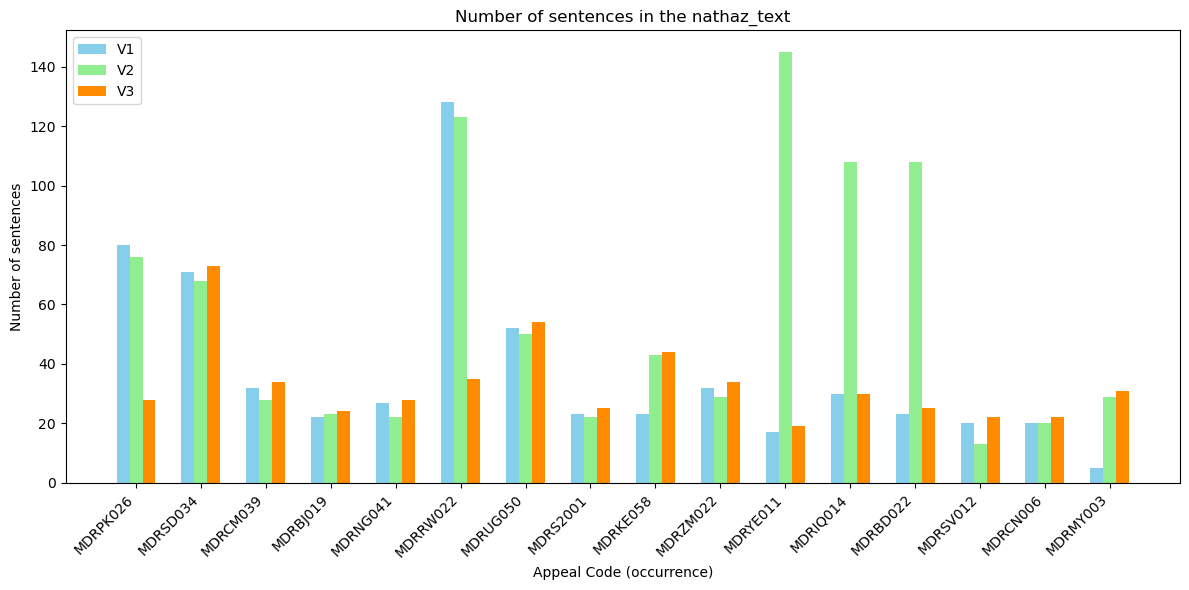

In [41]:
# Ensure both datasets are aligned in length by outer join on index
plot_data_v1 = plot_data_v1.reset_index(drop=True)
plot_data_v2 = plot_data_v2.reset_index(drop=True)
plot_data_v3 = plot_data_v3.reset_index(drop=True)

# Create a combined DataFrame so we can plot row-by-row
max_len = max(len(plot_data_v1), len(plot_data_v2), len(plot_data_v3))
plot_data_v1 = plot_data_v1.reindex(range(max_len))
plot_data_v2 = plot_data_v2.reindex(range(max_len))
plot_data_v3 = plot_data_v3.reindex(range(max_len))

# X positions for each row (not just each unique appealCode)
x = np.arange(max_len)
width = 0.2

fig, ax = plt.subplots(figsize=(12, 6))

# Bars for V1 and V2
ax.bar(x - width, plot_data_v1['len_nathaz_text'], width, label='V1', color='skyblue')
ax.bar(x , plot_data_v2['len_nathaz_text'], width, label='V2', color='lightgreen')
ax.bar(x + width, plot_data_v3['len_nathaz_text'], width, label='V3', color='darkorange')

# Use appeal codes (with index) for x-axis labels
# labels = [
#     f"{ac} ({i})" if pd.notna(ac) else ""
#     for i, ac in enumerate(plot_data_v1['appealCode'].fillna(""))
# ]
labels = plot_data_v1['appealCode']
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right')

# Labels and title
ax.set_ylabel("Number of sentences")
ax.set_xlabel("Appeal Code (occurrence)")
ax.set_title("Number of sentences in the nathaz_text")
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()
